# Qiskit (IBM) — Framework de Computação Quântica

## O que é o Qiskit?

**Qiskit** é o framework open-source de computação quântica da IBM. É o mais
popular do mundo e oferece uma pilha completa:

| Camada | O que faz |
|--------|-----------|
| `qiskit-terra` | Construção e compilação de circuitos |
| `qiskit-aer` | Simuladores locais (statevector, shot-based, noise) |
| `qiskit-ibm-runtime` | Acesso ao hardware real IBM Quantum |
| `qiskit-nature` / `qiskit-ml` | Aplicações (química, ML) |

## Filosofia central

`QuantumCircuit` é o **objeto central**. Você constrói o circuito porta a porta,
depois usa `transpile()` para adaptar ao hardware alvo e `execute()` / o
`Sampler` primitivo para rodar.

```
Construir → Transpilar → Executar → Analisar
```

**Qiskit domina em:**
- Ecossistema mais abrangente
- Integração direta com hardware IBM Quantum
- Documentação e comunidade enormes
- Aplicações: VQE, QAOA, QML, Química Quântica

## Exemplo 1 — Bell State (par entrelaçado)

O **Bell State** é o exemplo clássico de entrelaçamento quântico.
Dois qubits que, após medidos, **sempre concordam** — mesmo separados.

### Portas usadas
- **H (Hadamard):** coloca qubit 0 em superposição `|0⟩ + |1⟩`
- **CX (CNOT):** inverte qubit 1 **condicionado** ao estado do qubit 0

Resultado esperado: `00` e `11` com probabilidade ~50% cada

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

Contagens: {'11': 548, '00': 476}


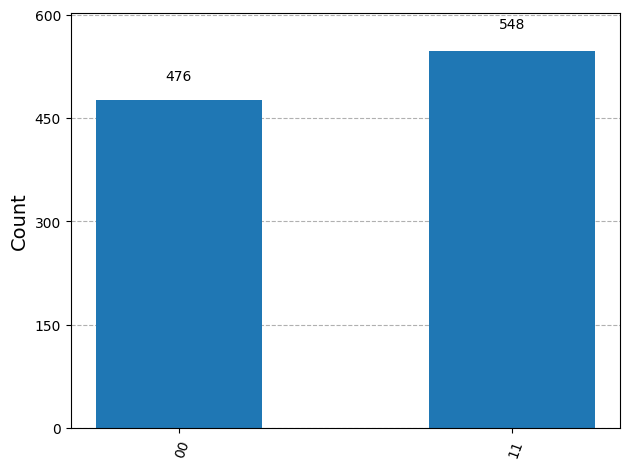

In [7]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# --- Construção do circuito ---
# QuantumCircuit(n_qubits, n_bits_clássicos)
qc = QuantumCircuit(2, 2)

qc.h(0)           # Hadamard no qubit 0 → superposição
qc.cx(0, 1)       # CNOT: qubit 0 controla qubit 1 → entrelaçamento
qc.measure([0, 1], [0, 1])  # mede qubits → bits clássicos

# Visualiza o circuito em texto
print(qc.draw('text'))

# --- Simulação local com AerSimulator ---
sim = AerSimulator()
job = sim.run(qc, shots=1024)  # 1024 execuções do circuito
result = job.result()
counts = result.get_counts()

print('\nContagens:', counts)
# Esperado: {'00': ~512, '11': ~512}
plot_histogram(counts)

## Exemplo 2 — Circuito GHZ (3 qubits entrelaçados)

O **estado GHZ** (Greenberger–Horne–Zeilinger) é a generalização do Bell State
para N qubits. É um estado de máximo entrelaçamento:

`|GHZ⟩ = (|000⟩ + |111⟩) / √2`

Se qualquer qubit for medido como 0, todos são 0. Idem para 1.

### Conceito: `draw()` para visualizar
O Qiskit oferece desenho do circuito em múltiplos formatos: `'text'`, `'mpl'` (matplotlib), `'latex'`.

In [8]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Estado GHZ com 3 qubits
ghz = QuantumCircuit(3, 3)

ghz.h(0)          # Superposição no qubit 0
ghz.cx(0, 1)      # Entrelaça qubit 1 com qubit 0
ghz.cx(0, 2)      # Entrelaça qubit 2 com qubit 0
ghz.measure([0, 1, 2], [0, 1, 2])

# Visualização do circuito (matplotlib)
print(ghz.draw('text'))  # 'mpl' requer pylatexenc; use 'text' para compatibilidade

     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 


Contagens GHZ: {'111': 996, '000': 1052}


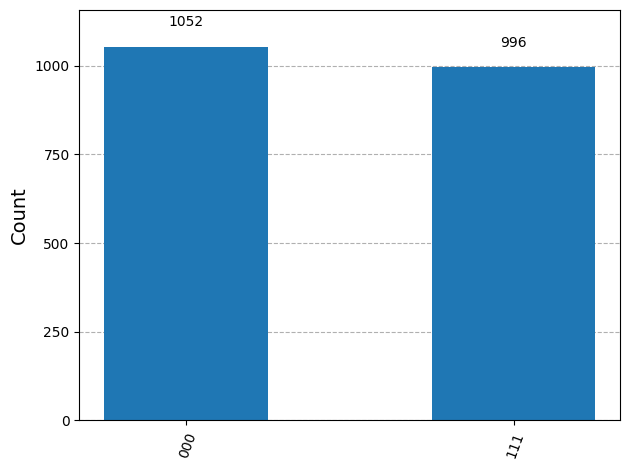

In [9]:
# Simulação
sim = AerSimulator()
resultado = sim.run(ghz, shots=2048).result()
counts = resultado.get_counts()

print('Contagens GHZ:', counts)
# Esperado: apenas '000' e '111'
plot_histogram(counts)

## Exemplo 3 — Teleportação Quântica

A **teleportação quântica** transfere o estado de um qubit para outro
usando entrelaçamento + 2 bits clássicos de comunicação.

> **Importante:** não teleporta matéria, apenas *informação quântica*.
> Ainda é necessário um canal clássico para completar o protocolo.

### Protocolo
1. Prepara par de Bell entre qubit 1 (Alice) e qubit 2 (Bob)
2. Alice entrelaça seu qubit de mensagem (qubit 0) com o qubit 1
3. Alice mede qubits 0 e 1 → envia 2 bits clássicos para Bob
4. Bob aplica correções (X e/ou Z) com base nos bits recebidos
5. Qubit 2 de Bob fica no estado original do qubit 0

In [10]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator

# 3 qubits: q0=mensagem (Alice), q1=emaranhado Alice, q2=emaranhado Bob
qr = QuantumRegister(3, 'q')
cr0 = ClassicalRegister(1, 'c0')  # medição de q0
cr1 = ClassicalRegister(1, 'c1')  # medição de q1
cr2 = ClassicalRegister(1, 'saida')  # resultado de Bob
teleporte = QuantumCircuit(qr, cr0, cr1, cr2)

# Passo 0: Estado a ser teleportado — superposição em q0
teleporte.h(0)
teleporte.barrier()

# Passo 1: Par de Bell entre q1 (Alice) e q2 (Bob)
teleporte.h(1)
teleporte.cx(1, 2)
teleporte.barrier()

# Passo 2: Alice emaranham q0 com q1
teleporte.cx(0, 1)
teleporte.h(0)
teleporte.barrier()

# Passo 3: Alice mede q0 e q1 → envia 2 bits clássicos para Bob
teleporte.measure(0, cr0[0])
teleporte.measure(1, cr1[0])

# Passo 4: Bob aplica correções com base nos bits recebidos
# if_test: executa a porta SE o registrador == valor esperado
with teleporte.if_test((cr1, 1)):  # Se cr1==1 → aplica X
    teleporte.x(2)
with teleporte.if_test((cr0, 1)):  # Se cr0==1 → aplica Z
    teleporte.z(2)

teleporte.measure(2, cr2[0])

print(teleporte.draw('text'))

         ┌───┐ ░            ░      ┌───┐ ░ ┌─┐                          »
    q_0: ┤ H ├─░────────────░───■──┤ H ├─░─┤M├──────────────────────────»
         └───┘ ░ ┌───┐      ░ ┌─┴─┐└───┘ ░ └╥┘┌─┐                       »
    q_1: ──────░─┤ H ├──■───░─┤ X ├──────░──╫─┤M├───────────────────────»
               ░ └───┘┌─┴─┐ ░ └───┘      ░  ║ └╥┘┌────── ┌───┐ ───────┐ »
    q_2: ──────░──────┤ X ├─░────────────░──╫──╫─┤ If-0  ┤ X ├  End-0 ├─»
               ░      └───┘ ░            ░  ║  ║ └──╥─── └───┘ ───────┘ »
   c0: 1/═══════════════════════════════════╩══╬════╬═══════════════════»
                                            0  ║ ┌──╨──┐                »
   c1: 1/══════════════════════════════════════╩═╡ 0x1 ╞════════════════»
                                               0 └─────┘                »
saida: 1/═══════════════════════════════════════════════════════════════»
                                                                        »
«                                   
«

## Exemplo 4 — Portas Parametrizadas e Variational Circuits

Circuitos **parametrizados** são a base do Quantum Machine Learning (QML).
Os ângulos das rotações são variáveis livres — **parâmetros treináveis**.

Isso permite criar circuitos que se comportam como **modelos de ML**,
onde o otimizador clássico ajusta os parâmetros para minimizar uma função de custo.

### Portas de rotação
- `Rx(θ)`: rotação em torno do eixo X da esfera de Bloch
- `Ry(θ)`: rotação em torno do eixo Y
- `Rz(θ)`: rotação em torno do eixo Z

In [11]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
import numpy as np

# --- Circuito com parâmetros simbólicos ---
theta = Parameter('θ')   # parâmetro simbólico
phi   = Parameter('φ')

qc = QuantumCircuit(2)
qc.ry(theta, 0)   # rotação Y parametrizada no qubit 0
qc.rx(phi, 1)     # rotação X parametrizada no qubit 1
qc.cx(0, 1)       # entrelaçamento

print('Parâmetros do circuito:', qc.parameters)
print(qc.draw('text'))

# --- Bind: substitui parâmetros por valores concretos ---
qc_concreto = qc.assign_parameters({theta: np.pi/4, phi: np.pi/3})
print('\nCircuito com valores concretos:')
print(qc_concreto.draw('text'))

# --- ParameterVector: define múltiplos parâmetros de uma vez ---
pesos = ParameterVector('w', 4)   # 4 parâmetros: w[0], w[1], w[2], w[3]

ansatz = QuantumCircuit(2)
ansatz.ry(pesos[0], 0)
ansatz.ry(pesos[1], 1)
ansatz.cx(0, 1)
ansatz.ry(pesos[2], 0)
ansatz.ry(pesos[3], 1)

print('\nAnsatz (circuito variacional):')
print(ansatz.draw('text'))

Parâmetros do circuito: ParameterView([Parameter(θ), Parameter(φ)])
     ┌───────┐     
q_0: ┤ Ry(θ) ├──■──
     ├───────┤┌─┴─┐
q_1: ┤ Rx(φ) ├┤ X ├
     └───────┘└───┘

Circuito com valores concretos:
     ┌─────────┐     
q_0: ┤ Ry(π/4) ├──■──
     ├─────────┤┌─┴─┐
q_1: ┤ Rx(π/3) ├┤ X ├
     └─────────┘└───┘

Ansatz (circuito variacional):
     ┌──────────┐     ┌──────────┐
q_0: ┤ Ry(w[0]) ├──■──┤ Ry(w[2]) ├
     ├──────────┤┌─┴─┐├──────────┤
q_1: ┤ Ry(w[1]) ├┤ X ├┤ Ry(w[3]) ├
     └──────────┘└───┘└──────────┘


## Exemplo 5 — Transpilação para Hardware Real

Hardware quântico real tem limitações físicas:
- **Topologia limitada**: nem todo par de qubits está conectado
- **Gate set nativo**: só executa certas portas (ex: CNOT, U)
- **Ruído**: cada porta adiciona erro

O `transpile()` **reescreve** o circuito para satisfazer essas restrições,
inserindo SWAPs extras quando necessário e decompondo portas complexas.

| Nível de otimização | Descrição |
|--------------------|-----------|
| 0 | Sem otimização (somente mapeamento) |
| 1 | Otimizações leves |
| 2 | Otimizações médias (padrão) |
| 3 | Otimizações agressivas |


In [12]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT

# Quantum Fourier Transform (QFT): algoritmo fundamental
# É o coração do algoritmo de Shor para fatoração de números
n_qubits = 4
qft = QFT(n_qubits)

print('Circuito QFT original:')
print(qft.draw('text'))

# Transpila para o simulador (como se fosse hardware real)
sim = AerSimulator()
qft_transpilado = transpile(qft, backend=sim, optimization_level=3)

print(f'\nGates antes da transpilação:  {qft.count_ops()}')
print(f'Gates após transpilação (opt=3): {qft_transpilado.count_ops()}')
print(f'Profundidade: {qft_transpilado.depth()} camadas')

Circuito QFT original:
     ┌──────┐
q_0: ┤0     ├
     │      │
q_1: ┤1     ├
     │  QFT │
q_2: ┤2     ├
     │      │
q_3: ┤3     ├
     └──────┘

Gates antes da transpilação:  OrderedDict({'QFT': 1})
Gates após transpilação (opt=3): OrderedDict({'cp': 6, 'h': 4})
Profundidade: 7 camadas


C:\Users\jlbraga\AppData\Local\Temp\ipykernel_37064\539577139.py:8: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft = QFT(n_qubits)


## Exemplo 6 — Ruído: Simulação Realista

O Qiskit Aer permite simular **ruído quântico** que existe no hardware real.

Tipos de ruído:
- **Bit flip (`X`)**: qubit muda de estado inesperadamente
- **Phase flip (`Z`)**: fase relativa é invertida
- **Depolarizing**: ruído isotrópico mais realista
- **Readout error**: erro na medição final

Simular com ruído permite estimar como um circuito se comportará em
hardware real **antes** de submetê-lo.

Ideal (sem ruído):   {'00': 977, '11': 1071}
Ruidoso (5% / 10%): {'00': 1007, '11': 933, '01': 58, '10': 50}


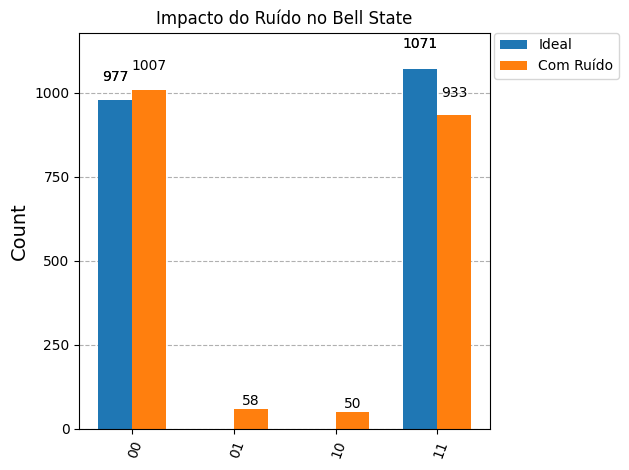

In [13]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram

# --- Circuito Bell State ---
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

# --- Modelo de ruído ---
noise_model = NoiseModel()

# 5% de erro depolarizante em portas de 1 qubit
erro_1q = depolarizing_error(0.05, 1)
noise_model.add_all_qubit_quantum_error(erro_1q, ['h', 'x'])

# 10% de erro depolarizante em portas de 2 qubits (CNOT)
erro_2q = depolarizing_error(0.10, 2)
noise_model.add_all_qubit_quantum_error(erro_2q, ['cx'])

# --- Simulação SEM ruído ---
sim_ideal = AerSimulator()
counts_ideal = sim_ideal.run(qc, shots=2048).result().get_counts()

# --- Simulação COM ruído ---
sim_ruidoso = AerSimulator(noise_model=noise_model)
counts_ruidoso = sim_ruidoso.run(qc, shots=2048).result().get_counts()

print('Ideal (sem ruído):  ', counts_ideal)
print('Ruidoso (5% / 10%):', counts_ruidoso)
# Com ruído, '01' e '10' aparecem — erros do hardware

from qiskit.visualization import plot_histogram
plot_histogram([counts_ideal, counts_ruidoso],
               legend=['Ideal', 'Com Ruído'],
               title='Impacto do Ruído no Bell State')

## Quando usar Qiskit?

```
✅ Quer usar hardware IBM Quantum real
✅ Precisa de simuladores confiáveis (Aer)
✅ Implementa algoritmos quânticos cl‎ássicos (Shor, Grover, VQE, QAOA)
✅ Quer a maior comunidade e documentação
✅ Química quântica (qiskit-nature)
✅ QML com circuitos parametrizados

❌ Hardware Google (use Cirq)
❌ Diferenciação automática avançada (use PennyLane)
❌ Controle de scheduling de baixo nível por Moments
```

## Resumo da API

| Objeto / Função | Papel |
|-----------------|-------|
| `QuantumCircuit(n, m)` | Cria circuito com n qubits, m bits clássicos |
| `.h(i)`, `.cx(i,j)`, `.ry(θ,i)` | Aplica porta no qubit i |
| `.measure(q, c)` | Liga qubit q ao bit clássico c |
| `.draw('mpl')` | Visualiza o circuito |
| `transpile(qc, backend)` | Adapta para hardware alvo |
| `AerSimulator()` | Simulador local |
| `result.get_counts()` | Dicionário de resultados de medição |